In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme()

pd.set_option('display.max_columns', None)

# Load your financial data
df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

funds = [   
    'quanstream', 
    'm1', 
    'vadantia', 
    # 'enko', 
    'wizard_quant', 
    'arr', 
    'r_squared', 
    'shiprock', 
    'grasshoper',
    # 'edge_capital',
    '26_miles',
    'adar1',
    'coban_clarion_multi_asset',
    # 'coban_pod_1',
    # 'coban_orca',
    'spear_digital',
    'blackrock_sta'
]

# Ensure we keep sp500 for the analysis later
cols_to_keep = funds + ['sp500']
cols_to_keep = [c for c in cols_to_keep if c in df.columns]

WIZARD_QUANT_LEVERAGE = True
if WIZARD_QUANT_LEVERAGE and 'wizard_quant' in df.columns:
    df['wizard_quant'] *= 2 - 0.04 / 12
    
df = df[cols_to_keep]
df_full = df.copy()
df = df[df.index >= pd.to_datetime('2022-01-01')]


df.head()

,quanstream,m1,vadantia,wizard_quant,arr,r_squared,shiprock,grasshoper,26_miles,adar1,coban_clarion_multi_asset,coban_pod_1,coban_orca,spear_digital,blackrock_sta,sp500
date,,,,,,,,,,,,,,,,
2022-01-01,0.055072,NaN,0.0077,0.004992,-0.0251,-0.0034,0.0137,NaN,0.0031,-0.028,0.024,0.056,NaN,0.0052,NaN,-0.051747
2022-02-01,-0.001088,NaN,0.0387,0.035141,0.0507,0.0210,-0.0062,NaN,0.0647,0.015,0.014,0.013,NaN,0.0211,NaN,-0.029942
2022-03-01,0.014212,NaN,-0.0444,0.067687,0.1287,0.0321,0.0475,NaN,0.0660,0.024,0.062,-0.018,NaN,0.0010,NaN,0.037130
2022-04-01,0.069832,NaN,0.0342,-0.000799,0.0328,0.0031,-0.0018,NaN,0.0936,-0.027,0.049,0.065,NaN,0.0000,NaN,-0.087202
2022-05-01,0.072532,NaN,0.0743,0.054309,0.0524,0.0141,0.0211,NaN,0.0734,-0.031,0.003,0.026,NaN,0.0000,NaN,0.001834


/Users/arthurdhonneur/Desktop/Athenee/athenee_hf_pflio/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2407: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Fitted Student-t Copula Degrees of Freedom: 10.00
Fitted Clayton Copula Theta: 1.00


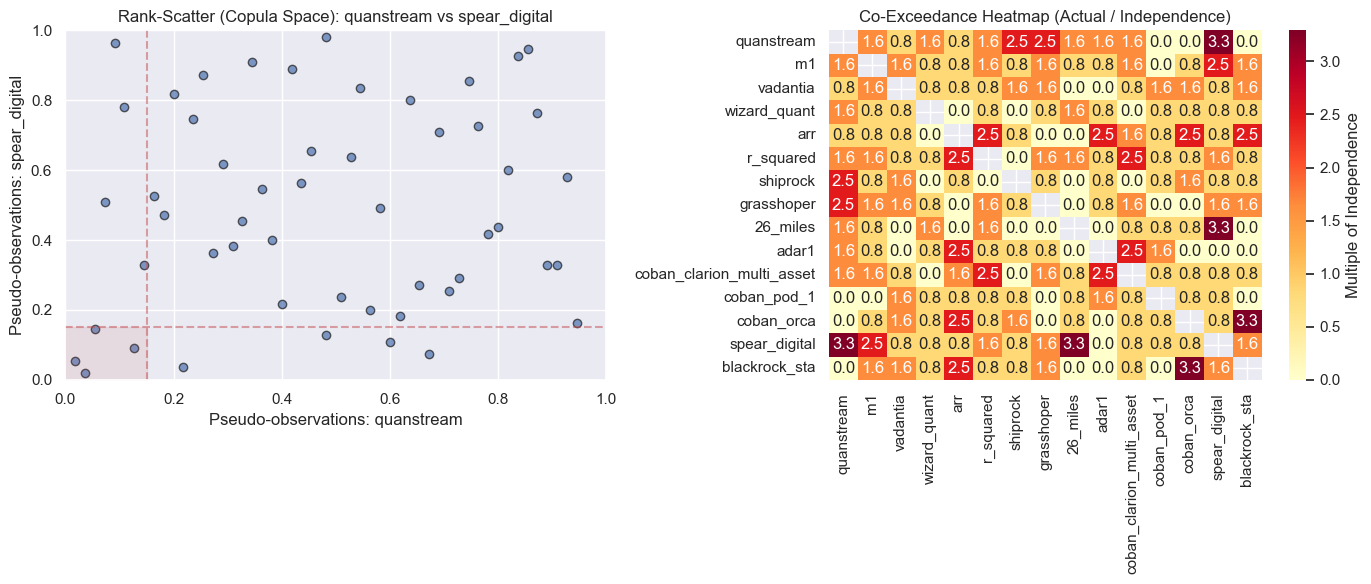

,Fund Pair,Linear Correlation,Left-Tail Correlation,Lambda_L
0,26_miles - spear_digital,0.064516,-0.233217,0.493827
1,coban_orca - blackrock_sta,0.276381,-0.289754,0.493827
2,quanstream - spear_digital,0.203500,0.001694,0.493827
3,r_squared - coban_clarion_multi_asset,0.096261,-0.557413,0.370370
4,arr - adar1,0.096920,-0.404027,0.370370
5,arr - r_squared,0.165921,-0.193423,0.370370
6,arr - blackrock_sta,0.096756,-0.355306,0.370370
7,m1 - spear_digital,0.212202,-0.187778,0.370370
8,quanstream - grasshoper,0.170966,-0.404320,0.370370
9,quanstream - shiprock,0.127698,-0.261090,0.370370


In [17]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.optimize import minimize

# 1. DEPENDENCIES & DATA PREPARATION
# Ensure we're using the columns corresponding to the funds
funds_cols = [c for c in df.columns if c != 'sp500']

# Transform to empirical uniform margins (pseudo-observations)
# U = Rank(R) / (T + 1)
U = df[funds_cols].rank() / (len(df) + 1)

# 2. QUANTIFY TAIL DEPENDENCE METRICS
q = 0.15

# Empirical Lower Tail Dependence Coefficient (λ_L)
lambda_L_matrix = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for f1 in funds_cols:
    for f2 in funds_cols:
        if f1 == f2:
            lambda_L_matrix.loc[f1, f2] = 1.0
        else:
            joint_prob = ((U[f1] <= q) & (U[f2] <= q)).mean()
            lambda_L_matrix.loc[f1, f2] = joint_prob / q

# Pearson and Spearman correlation matrices
corr_pearson = df[funds_cols].corr(method='pearson')
corr_spearman = df[funds_cols].corr(method='spearman')

# Left-Tail Correlation Matrix
left_tail_corr = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for f1 in funds_cols:
    for f2 in funds_cols:
        if f1 == f2:
            left_tail_corr.loc[f1, f2] = 1.0
        else:
            mask = (U[f1] <= q) | (U[f2] <= q)
            if mask.sum() > 1:
                left_tail_corr.loc[f1, f2] = df.loc[mask, f1].corr(df.loc[mask, f2])
            else:
                left_tail_corr.loc[f1, f2] = np.nan

# 3. COPULA FITTING
# Fit a Student-t Copula to extract the degrees of freedom
def t_copula_nll(nu, u, R):
    try:
        nu = nu[0]
        if nu <= 2.01 or nu > 100:
            return 1e10
        d = u.shape[1]
        x = stats.t.ppf(u, df=nu)
        invR = np.linalg.inv(R)
        detR = np.linalg.det(R)
        q_form = np.sum(np.dot(x, invR) * x, axis=1)
        
        log_joint = (math.lgamma((nu + d)/2) - math.lgamma(nu/2) 
                     - (d/2)*np.log(nu*np.pi) - 0.5*np.log(detR) 
                     - ((nu + d)/2)*np.log(1 + q_form/nu))
                     
        log_margins = (math.lgamma((nu + 1)/2) - math.lgamma(nu/2)
                       - 0.5*np.log(nu*np.pi) 
                       - ((nu + 1)/2)*np.log(1 + x**2/nu))
                       
        ll = np.sum(log_joint - np.sum(log_margins, axis=1))
        if np.isnan(ll) or np.isinf(ll):
            return 1e10
        return -ll
    except Exception:
        return 1e10

R_hat = np.corrcoef(stats.norm.ppf(np.clip(U.values, 0.001, 0.999)), rowvar=False)
res_t = minimize(t_copula_nll, x0=[10.0], args=(np.clip(U.values, 0.01, 0.99), R_hat), bounds=[(2.1, 100)])
print(f"Fitted Student-t Copula Degrees of Freedom: {res_t.x[0]:.2f}")

# Fit a Clayton Copula (Optional but preferred)
def clayton_copula_nll(theta, u):
    try:
        theta = theta[0]
        if theta <= 0.01:
            return 1e10
        d = u.shape[1]
        
        term1 = np.sum(u**(-theta), axis=1) - d + 1
        if np.any(term1 <= 0):
            return 1e10
            
        log_term1 = -(1/theta + d) * np.log(term1)
        log_term2 = -(theta + 1) * np.sum(np.log(u), axis=1)
        
        j = np.arange(d)
        log_term3 = np.sum(np.log(1 + j*theta))
        
        ll = np.sum(log_term1 + log_term2 + log_term3)
        if np.isnan(ll) or np.isinf(ll):
            return 1e10
        return -ll
    except Exception:
        return 1e10

res_clayton = minimize(clayton_copula_nll, x0=[1.0], args=(np.clip(U.values, 0.01, 0.99),), bounds=[(0.01, 20)])
print(f"Fitted Clayton Copula Theta: {res_clayton.x[0]:.2f}")

# 4. VISUALIZATION
# Find critical pair
for f in lambda_L_matrix.columns:
    lambda_L_matrix.loc[f, f] = np.nan
crit_pair = lambda_L_matrix.stack().idxmax()
f1, f2 = crit_pair

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) Rank-Scatter Plot
axes[0].scatter(U[f1], U[f2], alpha=0.7, edgecolors='k')
axes[0].axvline(q, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(q, color='r', linestyle='--', alpha=0.5)
axes[0].fill_between([0, q], 0, q, color='r', alpha=0.1)
axes[0].set_title(f"Rank-Scatter (Copula Space): {f1} vs {f2}")
axes[0].set_xlabel(f"Pseudo-observations: {f1}")
axes[0].set_ylabel(f"Pseudo-observations: {f2}")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# b) Co-Exceedance Heatmap
co_exceedance = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for col1 in funds_cols:
    for col2 in funds_cols:
        if col1 == col2:
            co_exceedance.loc[col1, col2] = np.nan
        else:
            joint_prob = ((U[col1] <= q) & (U[col2] <= q)).mean()
            indep_prob = q * q
            co_exceedance.loc[col1, col2] = joint_prob / indep_prob

sns.heatmap(co_exceedance, annot=True, cmap="YlOrRd", ax=axes[1], fmt=".1f", cbar_kws={'label': 'Multiple of Independence'})
axes[1].set_title("Co-Exceedance Heatmap (Actual / Independence)")
plt.tight_layout()
plt.show()

# c) Comparative DataFrame/Table
pairs = []
for i in range(len(funds_cols)):
    for j in range(i+1, len(funds_cols)):
        col1 = funds_cols[i]
        col2 = funds_cols[j]
        pairs.append({
            'Fund Pair': f"{col1} - {col2}",
            'Linear Correlation': corr_pearson.loc[col1, col2],
            'Left-Tail Correlation': left_tail_corr.loc[col1, col2],
            'Lambda_L': lambda_L_matrix.loc[col1, col2]
        })

comp_df = pd.DataFrame(pairs).sort_values(by='Lambda_L', ascending=False).reset_index(drop=True)
display(comp_df.head(15))

,Annualized Mean,Annualized Std,Proxy Sharpe
coban_clarion_multi_asset,0.318600,0.079344,4.015419
m1,0.171240,0.054253,3.156331
26_miles,0.324337,0.105084,3.086469
grasshoper,0.246729,0.085271,2.893475
blackrock_sta,0.139930,0.056084,2.495019
coban_pod_1,0.294000,0.122966,2.390902
quanstream,0.249832,0.105700,2.363604
shiprock,0.238882,0.118060,2.023391
adar1,0.314791,0.155985,2.018080
r_squared,0.171946,0.088611,1.940452


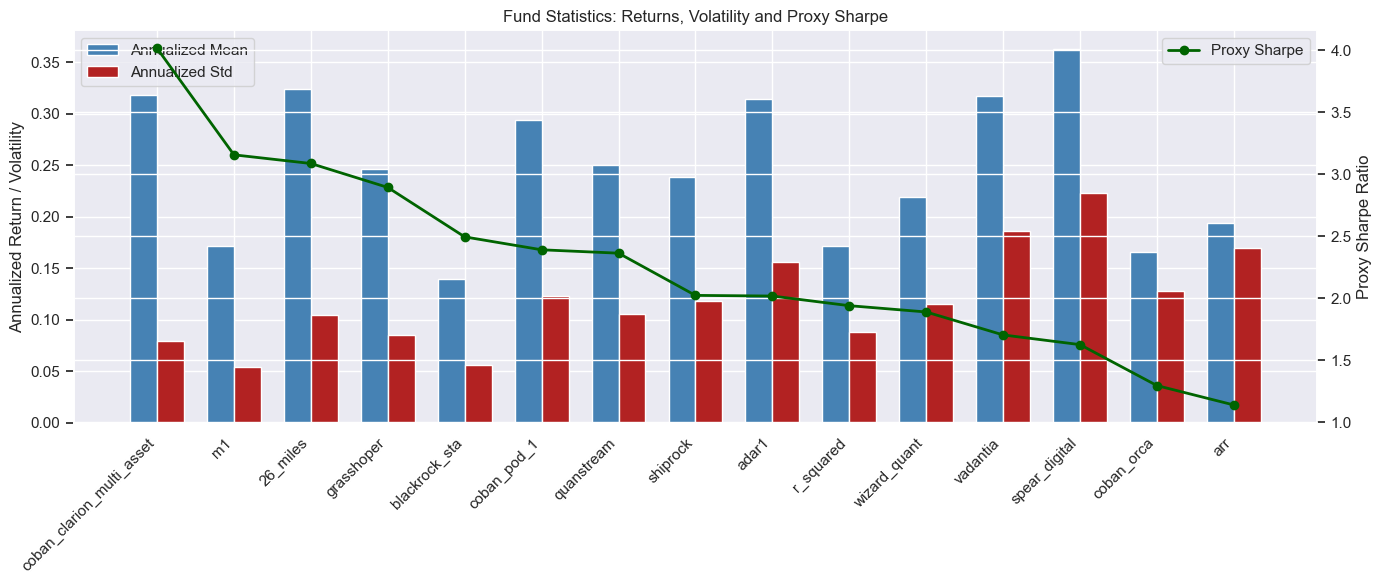

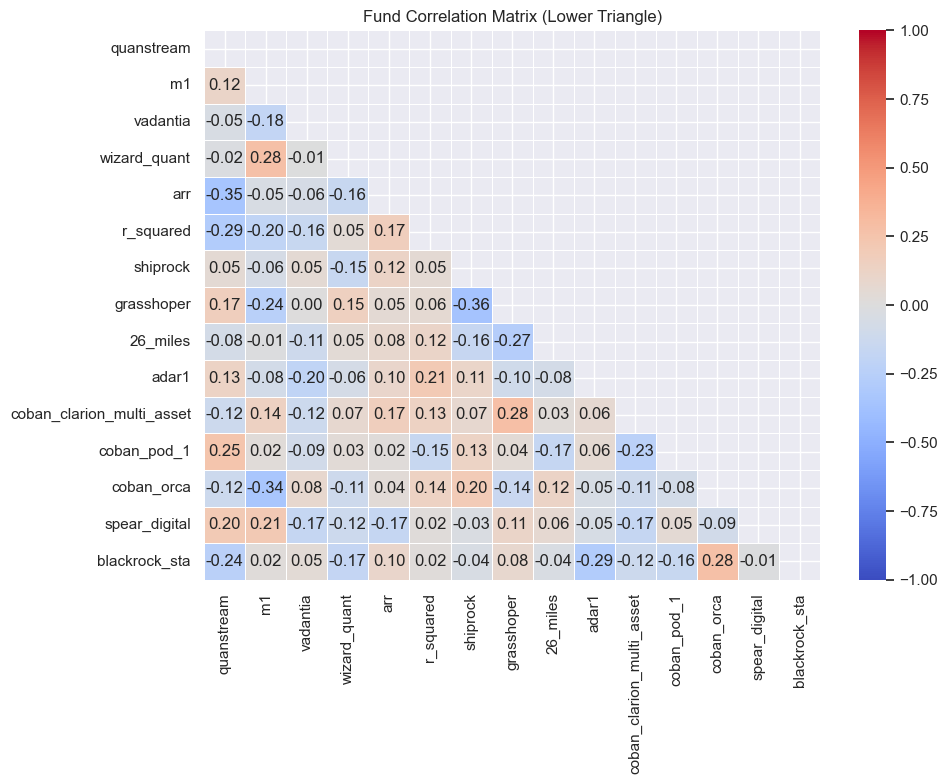

In [18]:
# Compute annualized metrics for individual funds
df_funds_full = df_full[funds].dropna(how='all')
df_funds = df[funds].dropna(how='all')

stats_df = pd.DataFrame(
    {
        "Annualized Mean": df_funds_full.mean() * 12,
        "Annualized Std": df_funds_full.std() * np.sqrt(12),
    }
)

stats_df["Proxy Sharpe"] = stats_df["Annualized Mean"] / stats_df["Annualized Std"]
stats_df_sorted = stats_df.sort_values(by="Proxy Sharpe", ascending=False)
display(stats_df_sorted)

# Plot returns and vol together for each fund with Proxy Sharpe on a line
fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(stats_df_sorted))
width = 0.35

ax1.bar(x - width/2, stats_df_sorted["Annualized Mean"], width, label='Annualized Mean', color='steelblue')
ax1.bar(x + width/2, stats_df_sorted["Annualized Std"], width, label='Annualized Std', color='firebrick')

ax1.set_ylabel('Annualized Return / Volatility')
ax1.set_title('Fund Statistics: Returns, Volatility and Proxy Sharpe')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df_sorted.index, rotation=45, ha='right')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, stats_df_sorted["Proxy Sharpe"], color='darkgreen', marker='o', linewidth=2, label='Proxy Sharpe')
ax2.set_ylabel('Proxy Sharpe Ratio')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Heatmap of correlation between the funds (lower triangle only)
corr_matrix = df_funds_full.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Fund Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

In [19]:
# --- Worst 10% SP500 Months Analysis (All Funds) ---
import plotly.graph_objects as go
import pandas as pd

def plot_worst_sp500_months_interactive(data_df, title_suffix="", start_date=None):
    df_plot = data_df.copy()
    if start_date:
        df_plot = df_plot[df_plot.index >= pd.to_datetime(start_date)]
        
    # Find worst 10% SP500 months
    q10_sp500 = df_plot['sp500'].quantile(0.10)
    worst_months = df_plot[df_plot['sp500'] <= q10_sp500].copy()
    
    # Sort by SP500 returns ascending
    worst_months = worst_months.sort_values(by='sp500', ascending=True)
    
    # Prepare data for plotting
    cols_to_plot = ['sp500'] + [f for f in funds if f in df_plot.columns]
    
    plot_data = worst_months[cols_to_plot].copy()
    plot_data.index = plot_data.index.strftime('%Y-%m') # Format dates for x-axis
    plot_data = plot_data * 100 # Convert to percentage
    
    # Create interactive bar plot with Plotly
    fig = go.Figure()
    
    # Add SP500 first (in black)
    fig.add_trace(go.Bar(
        x=plot_data.index,
        y=plot_data['sp500'],
        name='SP500',
        marker_color='black'
    ))
    
    # Add other funds
    for col in cols_to_plot:
        if col != 'sp500':
            fig.add_trace(go.Bar(
                x=plot_data.index,
                y=plot_data[col],
                name=col
            ))
            
    fig.update_layout(
        title=f'Performance During Worst 10% SP500 Months {title_suffix}',
        xaxis_title='Date',
        yaxis_title='Return (%)',
        barmode='group',
        hovermode='x unified',
        legend_title='Funds',
        height=600,
        width=1200,
        xaxis=dict(
            type='category',
            categoryorder='array',
            categoryarray=plot_data.index
        )
    )
    
    # Add horizontal line at 0
    fig.add_hline(y=0, line_width=1, line_color="black")
    
    fig.show()

# Plot using df_full starting from 2019
plot_worst_sp500_months_interactive(df_full, "(Using df_full, Since 2019)", start_date="2019-01-01")

# Plot using df
plot_worst_sp500_months_interactive(df, "(Using df)")

## Portfolios Construction

We construct four portfolios based on initial allocations (in millions):
1. **Monthly Equal Weight (Baseline)**: simple equal weighting of all funds rebalanced monthly.
2. **Drifting Initial Allocation**: initial capital is invested, weights drift without rebalancing.
3. **Monthly Rebalanced Initial Allocation**: weights are set to initial allocation proportions, rebalanced monthly.
4. **6-Month Rebalanced Initial Allocation**: weights are reset to initial allocation proportions every 6 months.

Initial exposure is 9.0M USD


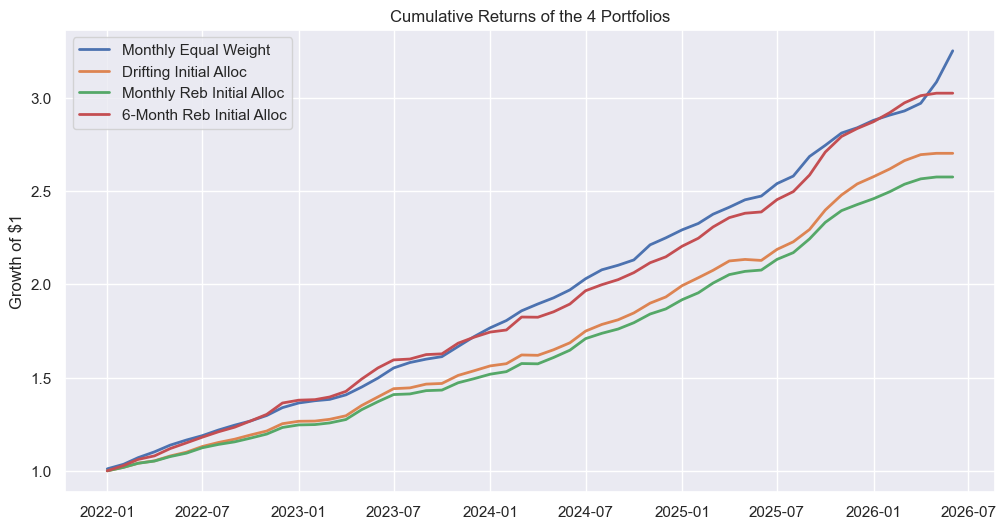

,Monthly Equal Weight,Drifting Initial Alloc,Monthly Reb Initial Alloc,6-Month Reb Initial Alloc
date,,,,
2022-01-01,0.010297,-0.000212,-0.000212,-0.000212
2022-02-01,0.024187,0.018719,0.018705,0.028082
2022-03-01,0.034618,0.021668,0.021432,0.032210
2022-04-01,0.028903,0.012169,0.011256,0.017904
2022-05-01,0.032740,0.024805,0.022912,0.036290


In [20]:
# Initial capital allocation per fund (in millions)
allocations = {
    # 'quanstream': 1,
    'm1': 1,
    'vadantia': 1.0,
    # 'enko': 1.0,
    'wizard_quant': 1.0,
    # 'arr': 0.5,
    'r_squared': 1.0,
    'shiprock': 1.0,
    'grasshoper': 2.0,
    # 'edge_capital': 1.0
    '26_miles': 1.0,
    'adar1':1,
    # 'coban_clarion_multi_asset': 1,
    # 'coban_pod_1': 1,
    # 'coban_orca': 1
}

s = 0
for k, v in allocations.items():
    s += v

print(f'Initial exposure is {s}M USD')

allocations_s = pd.Series(allocations)
# Align with available funds in df
allocations_s = allocations_s[allocations_s.index.isin(df_funds.columns)]

# 1. Monthly Equal Weight
eq_portfolio_return = df_funds.mean(axis=1)

# Base weights from initial allocation
w_init = allocations_s / allocations_s.sum()

# 2. Monthly Rebalanced Initial Allocation
monthly_reb_return = (df_funds * w_init).sum(axis=1)

# 3. Drifting Initial Allocation
cum_returns = (1 + df_funds).cumprod()
weights_drift = (cum_returns.shift(1).fillna(1.0) * allocations_s)
weights_drift = weights_drift.div(weights_drift.sum(axis=1), axis=0)
drifting_return = (df_funds * weights_drift).sum(axis=1)

# 4. 6-Month Rebalanced Initial Allocation
returns_6m = []
current_weights = w_init.copy()
for i in range(len(df_funds)):
    ret = (df_funds.iloc[i] * current_weights).sum()
    returns_6m.append(ret)
    if (i + 1) % 6 == 0:
        current_weights = w_init.copy()
    else:
        # drift the weights
        current_weights = current_weights * (1 + df_funds.iloc[i])
        current_weights = current_weights / current_weights.sum()

returns_6m_series = pd.Series(returns_6m, index=df_funds.index)

# Combine all portfolios
portfolios_df = pd.DataFrame({
    'Monthly Equal Weight': eq_portfolio_return,
    'Drifting Initial Alloc': drifting_return,
    'Monthly Reb Initial Alloc': monthly_reb_return,
    '6-Month Reb Initial Alloc': returns_6m_series
})

portfolios_df.dropna(inplace=True)

# Plot cumulative returns of the portfolios
cum_portfolios = (1 + portfolios_df).cumprod()
plt.figure(figsize=(12, 6))
for col in cum_portfolios.columns:
    plt.plot(cum_portfolios.index, cum_portfolios[col], label=col, linewidth=2)
plt.title('Cumulative Returns of the 4 Portfolios')
plt.ylabel('Growth of $1')
plt.legend()
plt.show()

portfolios_df.head()

## General Analysis

Applying the general analysis framework to each of the 4 portfolios.

In [21]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import yfinance as yf
from IPython.display import display, HTML

# Fetch WTI data once
sp500 = df_full['sp500'].dropna()
try:
    wti = yf.download('CL=F', start=df_full.index.min() - pd.Timedelta(days=31), end=df_full.index.max() + pd.Timedelta(days=31), progress=False)
    if isinstance(wti.columns, pd.MultiIndex):
        wti_close = wti['Close']['CL=F'].to_frame()
    else:
        wti_close = wti[['Close']]
    
    wti_monthly = wti_close.resample('ME').last()
    wti_returns = wti_monthly.pct_change()
    wti_returns.index = wti_returns.index.to_period('M').to_timestamp()
    wti_returns.columns = ['wti_return']
    
    analysis_df = df_full.join(wti_returns)
except Exception as e:
    print(f"Error fetching WTI data: {e}")
    analysis_df = df_full.copy()

def bootstrap_corr(x, y, method='pearson', block_size=1, iters=1000):
    np.random.seed(42)
    n = len(x)
    corrs = []
    indices = np.arange(n)
    for _ in range(iters):
        if block_size == 1:
            idx = np.random.choice(indices, size=n, replace=True)
        else:
            num_blocks = int(np.ceil(n / block_size))
            block_starts = np.random.choice(n - block_size + 1, size=num_blocks, replace=True)
            idx = [i for start in block_starts for i in range(start, start + block_size)][:n]
        x_samp = x.iloc[idx]
        y_samp = y.iloc[idx]
        corrs.append(x_samp.corr(y_samp, method=method))
    return np.nanpercentile(corrs, 2.5), np.nanpercentile(corrs, 97.5)

--- Dataset Info ---
Start Date: 2022-01-01
End Date:   2026-05-01
Time Elapsed: 1581 days (4.33 years)
Total Data Points: 53 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  100.00% (53/53)
SP500 Positive Months: 64.15% (34/53)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 100.00% (19/19)
Fund Negative when SP500 Positive: 0.00% (0/34)

--- Trading Metrics (n=53 months) ---
Annualized Mean Return: 0.2584
Annualized Volatility:  0.0315
Sharpe Ratio:           8.2146
CAGR:                   0.2907
Max Drawdown:           0.0000
Calmar Ratio:           nan

--- Joint Metrics (n=53 months) ---
Pearson Correlation:  0.1688
  - 95% CI (Standard Bootstrap): [-0.0669, 0.3987]
  - 95% CI (Block=3 Bootstrap):  [-0.0934, 0.4400]
Spearman Correlation: 0.2045
  - 95% CI (Standard Bootstrap): [-0.0526, 0.4434]
  - 95% CI (Block=3 Bootstrap):  [-0.1060, 0.4887]
Regression Alpha (Annualized): 0.2541 (t-stat: 16.6221)
Regression Beta:               0.0329 (t-stat:

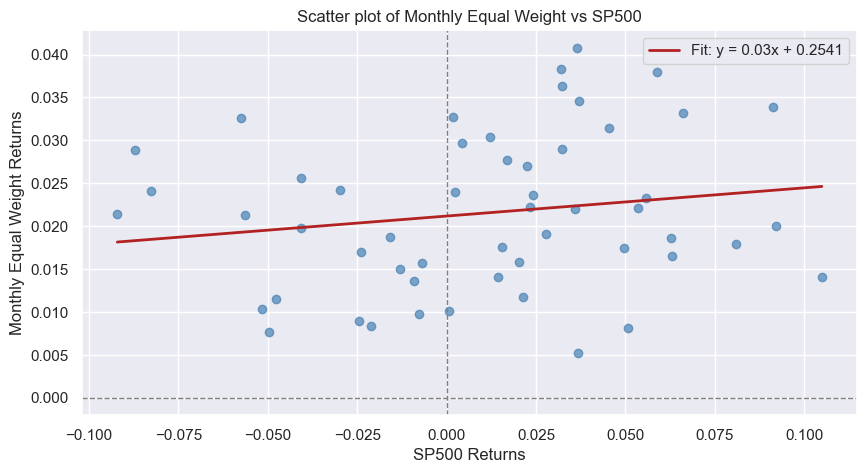

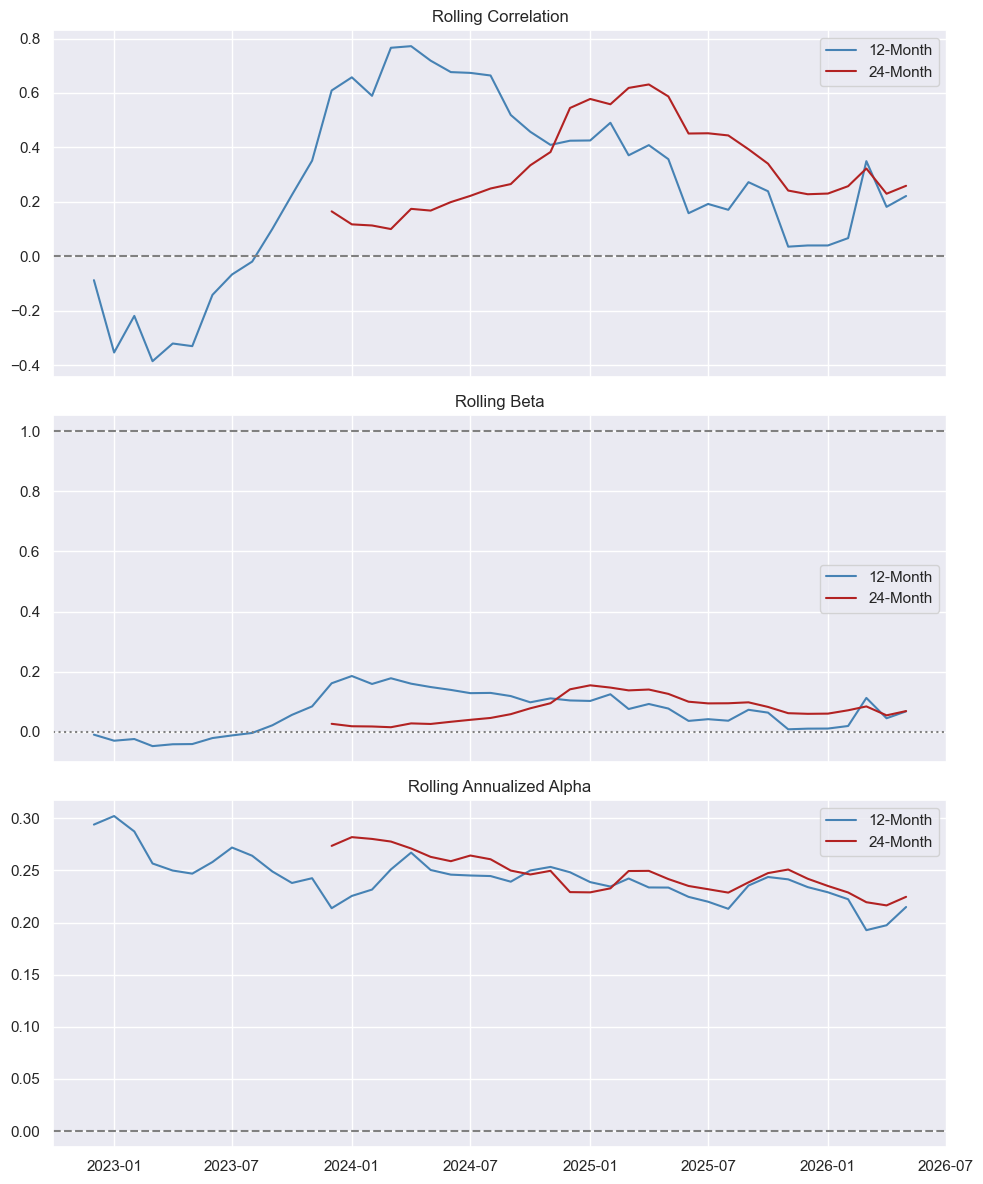

--- Dataset Info ---
Start Date: 2022-01-01
End Date:   2026-05-01
Time Elapsed: 1581 days (4.33 years)
Total Data Points: 53 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  94.34% (50/53)
SP500 Positive Months: 64.15% (34/53)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 89.47% (17/19)
Fund Negative when SP500 Positive: 2.94% (1/34)

--- Trading Metrics (n=53 months) ---
Annualized Mean Return: 0.2280
Annualized Volatility:  0.0383
Sharpe Ratio:           5.9485
CAGR:                   0.2526
Max Drawdown:           -0.0025
Calmar Ratio:           101.8380

--- Joint Metrics (n=53 months) ---
Pearson Correlation:  0.1576
  - 95% CI (Standard Bootstrap): [-0.0595, 0.3879]
  - 95% CI (Block=3 Bootstrap):  [-0.0980, 0.4008]
Spearman Correlation: 0.1455
  - 95% CI (Standard Bootstrap): [-0.1365, 0.4259]
  - 95% CI (Block=3 Bootstrap):  [-0.1370, 0.4318]
Regression Alpha (Annualized): 0.2232 (t-stat: 11.9562)
Regression Beta:               0.0374 (t-s

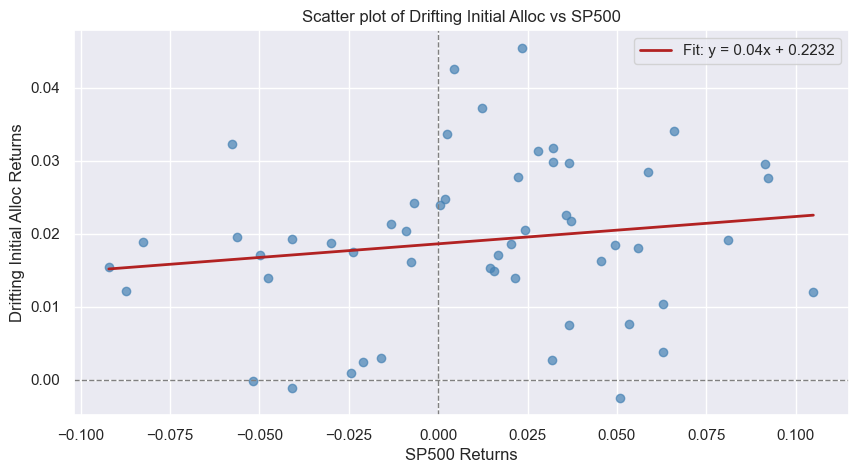

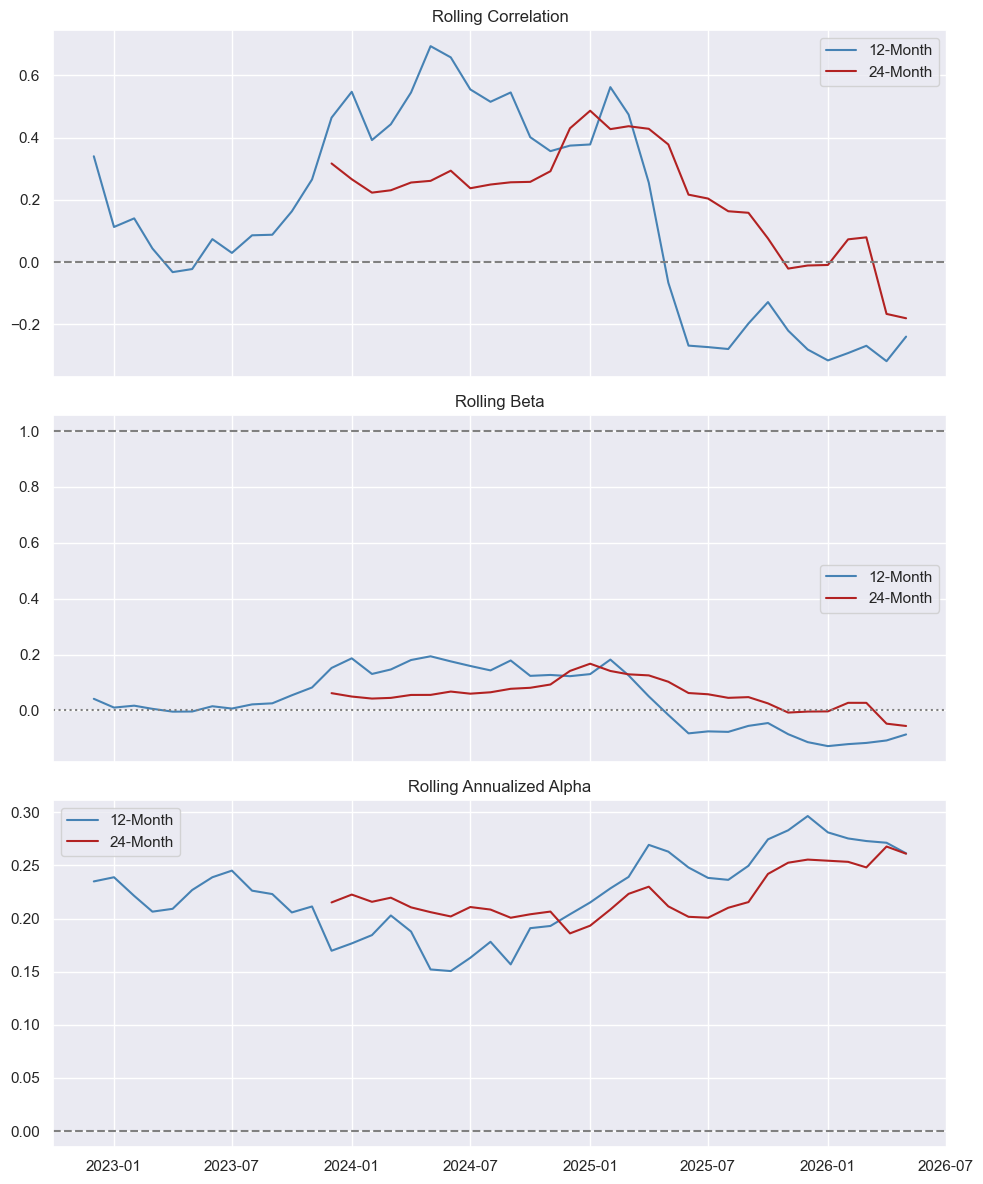

--- Dataset Info ---
Start Date: 2022-01-01
End Date:   2026-05-01
Time Elapsed: 1581 days (4.33 years)
Total Data Points: 53 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  96.23% (51/53)
SP500 Positive Months: 64.15% (34/53)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 89.47% (17/19)
Fund Negative when SP500 Positive: 0.00% (0/34)

--- Trading Metrics (n=53 months) ---
Annualized Mean Return: 0.2168
Annualized Volatility:  0.0351
Sharpe Ratio:           6.1702
CAGR:                   0.2390
Max Drawdown:           -0.0010
Calmar Ratio:           246.7623

--- Joint Metrics (n=53 months) ---
Pearson Correlation:  0.2038
  - 95% CI (Standard Bootstrap): [-0.0206, 0.4252]
  - 95% CI (Block=3 Bootstrap):  [-0.0558, 0.4406]
Spearman Correlation: 0.1867
  - 95% CI (Standard Bootstrap): [-0.1015, 0.4583]
  - 95% CI (Block=3 Bootstrap):  [-0.1132, 0.4721]
Regression Alpha (Annualized): 0.2111 (t-stat: 12.4430)
Regression Beta:               0.0443 (t-s

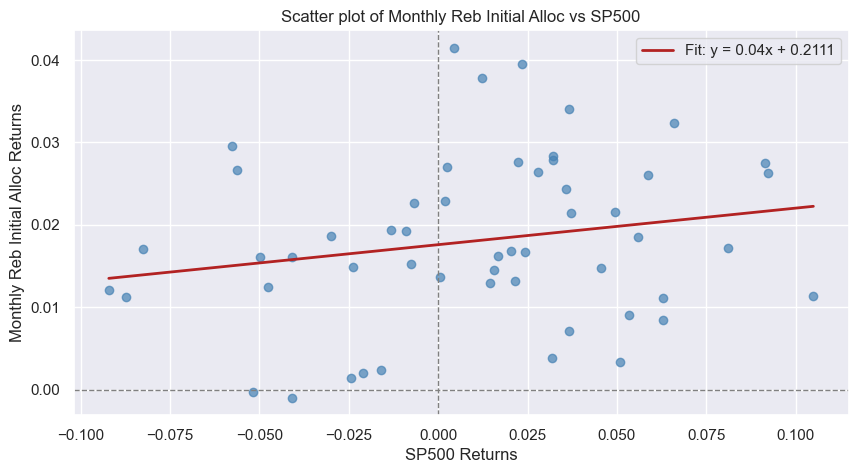

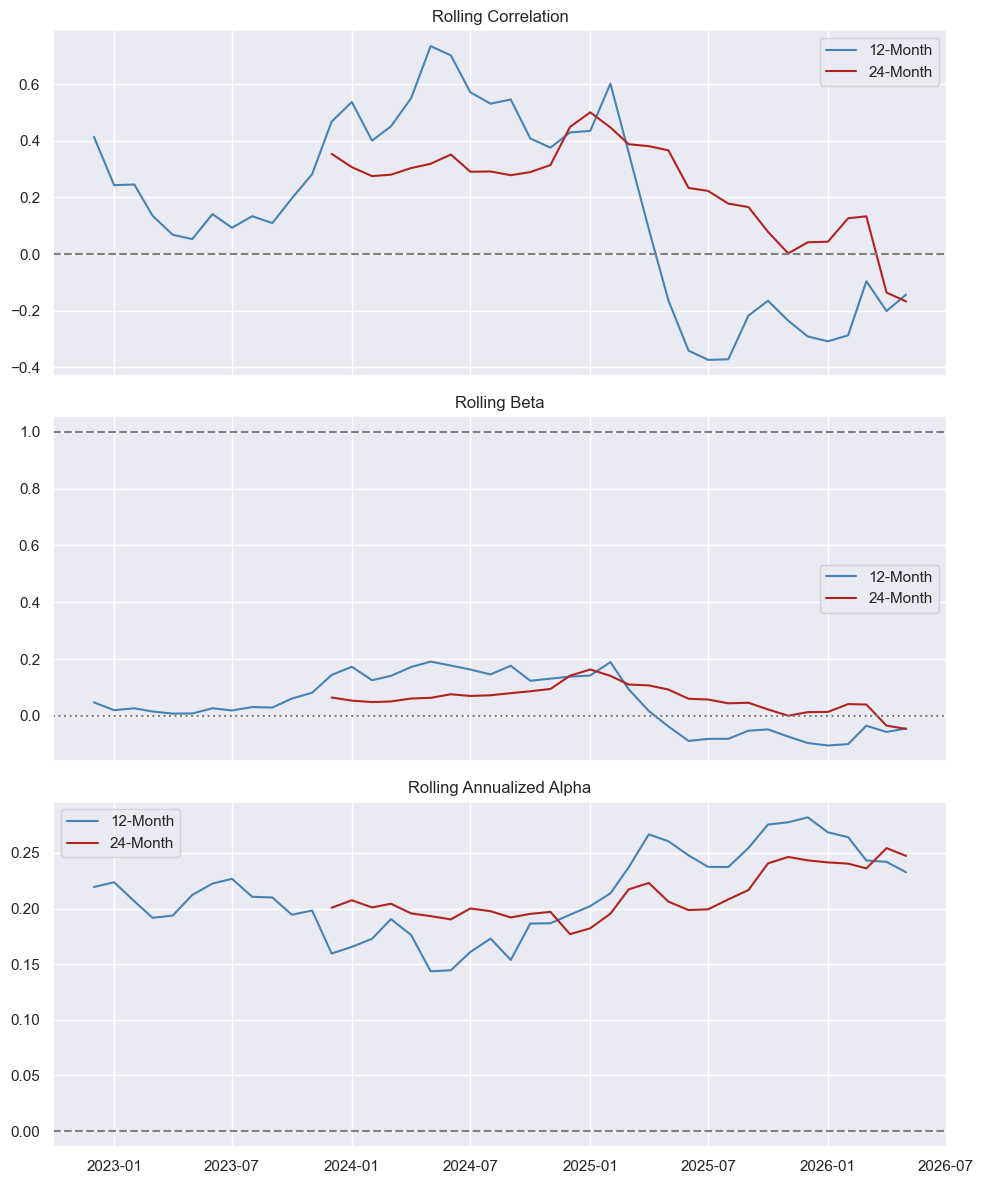

--- Dataset Info ---
Start Date: 2022-01-01
End Date:   2026-05-01
Time Elapsed: 1581 days (4.33 years)
Total Data Points: 53 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  96.23% (51/53)
SP500 Positive Months: 64.15% (34/53)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 89.47% (17/19)
Fund Negative when SP500 Positive: 0.00% (0/34)

--- Trading Metrics (n=53 months) ---
Annualized Mean Return: 0.2542
Annualized Volatility:  0.0424
Sharpe Ratio:           5.9983
CAGR:                   0.2850
Max Drawdown:           -0.0006
Calmar Ratio:           512.1070

--- Joint Metrics (n=53 months) ---
Pearson Correlation:  0.0980
  - 95% CI (Standard Bootstrap): [-0.1388, 0.3347]
  - 95% CI (Block=3 Bootstrap):  [-0.1468, 0.3494]
Spearman Correlation: 0.0947
  - 95% CI (Standard Bootstrap): [-0.1897, 0.3713]
  - 95% CI (Block=3 Bootstrap):  [-0.1587, 0.3717]
Regression Alpha (Annualized): 0.2509 (t-stat: 12.0620)
Regression Beta:               0.0257 (t-s

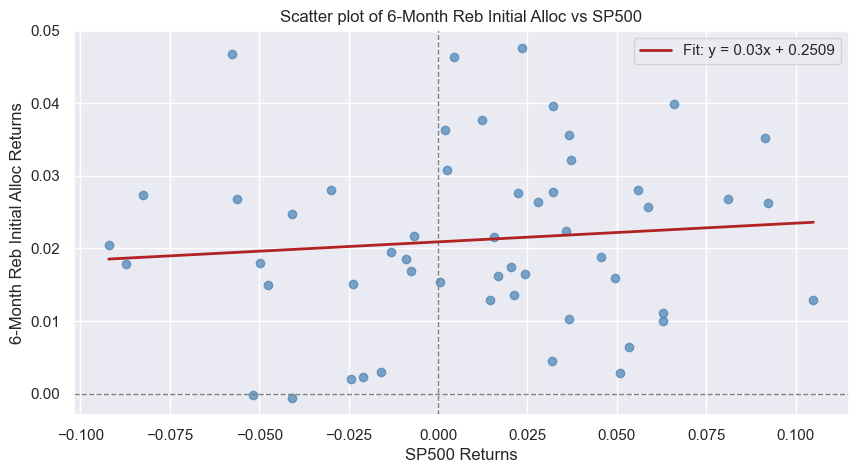

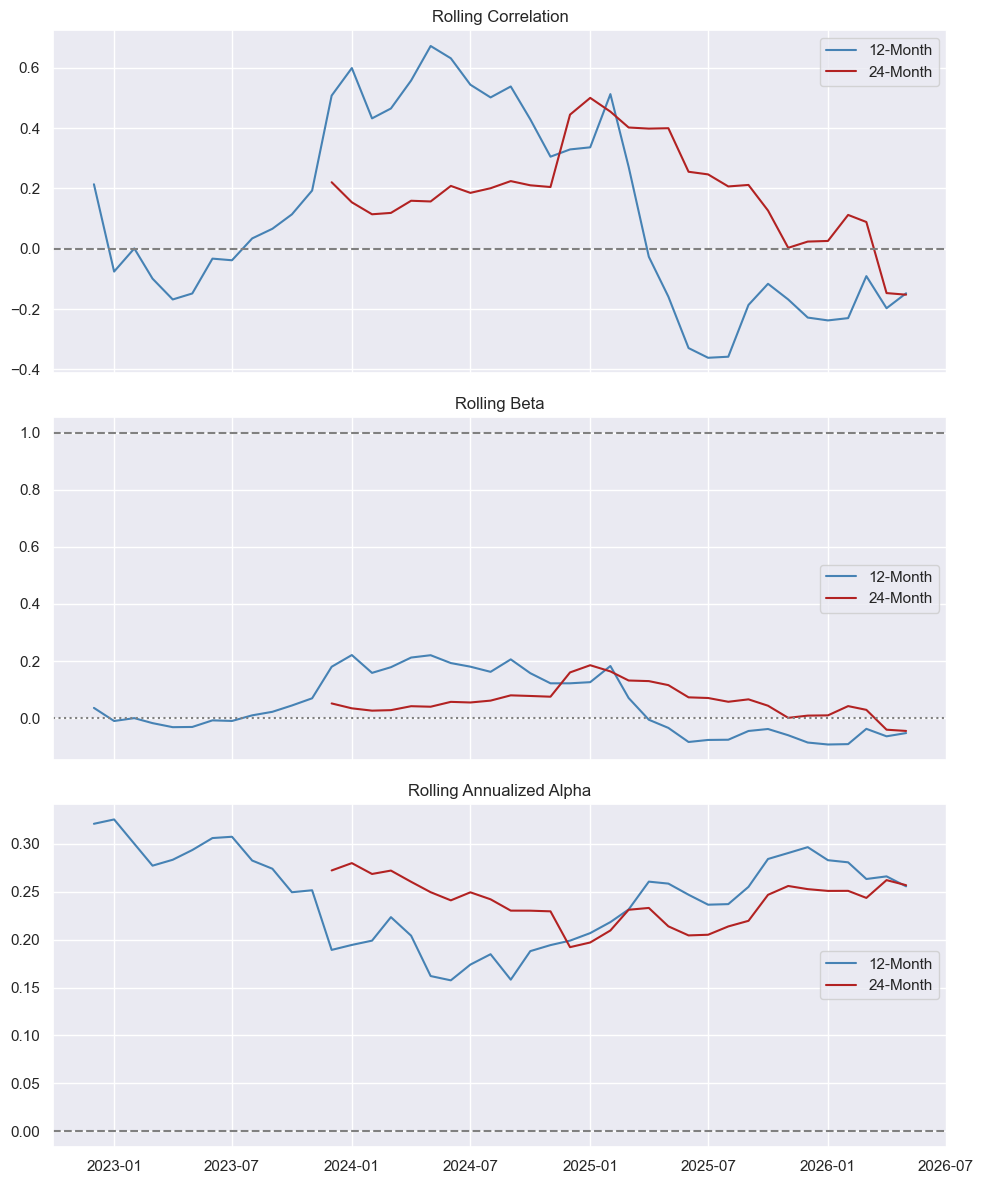

In [22]:
# Run analysis for each portfolio
for port_name in portfolios_df.columns:
    display(HTML(f"<h3 style='color: firebrick;'>============================================<br>ANALYSIS FOR {port_name}<br>============================================</h3>"))
    
    fund = portfolios_df[port_name]
    
    # Align dates
    common_idx = fund.index.intersection(sp500.index)
    fund_aligned = fund.loc[common_idx]
    sp500_aligned = sp500.loc[common_idx]
    
    n_months = len(fund_aligned)
    if n_months == 0:
        continue
        
    start_date = fund_aligned.index.min()
    end_date = fund_aligned.index.max()
    time_elapsed = end_date - start_date
    years_elapsed = time_elapsed.days / 365.25

    print("--- Dataset Info ---")
    print(f"Start Date: {start_date.date()}")
    print(f"End Date:   {end_date.date()}")
    print(f"Time Elapsed: {time_elapsed.days} days ({years_elapsed:.2f} years)")
    print(f"Total Data Points: {n_months} months")

    fund_pos_months = (fund_aligned > 0).sum()
    sp500_pos_months = (sp500_aligned > 0).sum()
    print("\n--- Positive Months (Hit Rates) ---")
    print(f"Fund Positive Months:  {fund_pos_months/n_months:.2%} ({fund_pos_months}/{n_months})")
    print(f"SP500 Positive Months: {sp500_pos_months/n_months:.2%} ({sp500_pos_months}/{n_months})")

    sp500_neg_mask = sp500_aligned < 0
    sp500_pos_mask = sp500_aligned > 0
    n_sp500_neg = sp500_neg_mask.sum()
    n_sp500_pos = sp500_pos_mask.sum()

    fund_pos_when_sp500_neg = (fund_aligned[sp500_neg_mask] > 0).sum()
    fund_neg_when_sp500_pos = (fund_aligned[sp500_pos_mask] < 0).sum()
    print("\n--- Conditional Hit Rates ---")
    print(f"Fund Positive when SP500 Negative: {fund_pos_when_sp500_neg / n_sp500_neg if n_sp500_neg > 0 else np.nan:.2%} ({fund_pos_when_sp500_neg}/{n_sp500_neg})")
    print(f"Fund Negative when SP500 Positive: {fund_neg_when_sp500_pos / n_sp500_pos if n_sp500_pos > 0 else np.nan:.2%} ({fund_neg_when_sp500_pos}/{n_sp500_pos})")

    # Trading Metrics
    mean_ret = fund_aligned.mean() * 12
    vol = fund_aligned.std() * np.sqrt(12)
    sharpe = mean_ret / vol if vol != 0 else np.nan

    cum_ret = (1 + fund_aligned).prod()
    n_years = n_months / 12
    cagr = cum_ret**(1/n_years) - 1

    cum_wealth = (1 + fund_aligned).cumprod()
    peak = cum_wealth.cummax()
    drawdown = (cum_wealth - peak) / peak
    max_drawdown = drawdown.min()

    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    print(f"\n--- Trading Metrics (n={n_months} months) ---")
    print(f"Annualized Mean Return: {mean_ret:.4f}")
    print(f"Annualized Volatility:  {vol:.4f}")
    print(f"Sharpe Ratio:           {sharpe:.4f}")
    print(f"CAGR:                   {cagr:.4f}")
    print(f"Max Drawdown:           {max_drawdown:.4f}")
    print(f"Calmar Ratio:           {calmar:.4f}")

    # Joint Metrics
    pearson_corr = fund_aligned.corr(sp500_aligned, method='pearson')
    spearman_corr = fund_aligned.corr(sp500_aligned, method='spearman')

    pearson_std_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='pearson', block_size=1)
    pearson_blk_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='pearson', block_size=3)
    spearman_std_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='spearman', block_size=1)
    spearman_blk_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='spearman', block_size=3)

    X = sm.add_constant(sp500_aligned)
    model = sm.OLS(fund_aligned, X).fit()
    alpha = model.params['const'] * 12
    beta = model.params['sp500']
    alpha_tstat = model.tvalues['const']
    beta_tstat = model.tvalues['sp500']

    print(f"\n--- Joint Metrics (n={n_months} months) ---")
    print(f"Pearson Correlation:  {pearson_corr:.4f}")
    print(f"  - 95% CI (Standard Bootstrap): [{pearson_std_ci[0]:.4f}, {pearson_std_ci[1]:.4f}]")
    print(f"  - 95% CI (Block=3 Bootstrap):  [{pearson_blk_ci[0]:.4f}, {pearson_blk_ci[1]:.4f}]")
    print(f"Spearman Correlation: {spearman_corr:.4f}")
    print(f"  - 95% CI (Standard Bootstrap): [{spearman_std_ci[0]:.4f}, {spearman_std_ci[1]:.4f}]")
    print(f"  - 95% CI (Block=3 Bootstrap):  [{spearman_blk_ci[0]:.4f}, {spearman_blk_ci[1]:.4f}]")
    print(f"Regression Alpha (Annualized): {alpha:.4f} (t-stat: {alpha_tstat:.4f})")
    print(f"Regression Beta:               {beta:.4f} (t-stat: {beta_tstat:.4f})")

    if 'wti_return' in analysis_df.columns:
        wti_clean = pd.DataFrame({'wti_return': analysis_df['wti_return'], 'fund': fund}).dropna()
        if len(wti_clean) > 10:
            X_wti = sm.add_constant(wti_clean['wti_return'])
            model_wti = sm.OLS(wti_clean['fund'], X_wti).fit()
            print(f"\n--- WTI Joint Metrics (n={len(wti_clean)} months) ---")
            print(f"Regression Alpha (Annualized): {model_wti.params['const'] * 12:.4f} (t-stat: {model_wti.tvalues['const']:.4f})")
            print(f"Regression Beta (WTI):         {model_wti.params['wti_return']:.4f} (t-stat: {model_wti.tvalues['wti_return']:.4f})")

    # Capture Ratios
    up_months_fund = fund_aligned[sp500_pos_mask]
    down_months_fund = fund_aligned[sp500_neg_mask]
    
    up_capture = up_months_fund.mean() / sp500_aligned[sp500_pos_mask].mean() if len(up_months_fund) > 0 else np.nan
    down_capture = down_months_fund.mean() / sp500_aligned[sp500_neg_mask].mean() if len(down_months_fund) > 0 else np.nan

    print("\n--- Capture Ratios ---")
    print(f"Upside Capture:   {up_capture:.4f} (n={len(up_months_fund)})")
    print(f"Downside Capture: {down_capture:.4f} (n={len(down_months_fund)})")

    # Conditional Metrics
    if len(up_months_fund) > 2:
        model_up = sm.OLS(up_months_fund, sm.add_constant(sp500_aligned[sp500_pos_mask])).fit()
        print(f"\n--- Up Months Metrics (n={len(up_months_fund)}) ---")
        print(f"Up Alpha (Annualized): {model_up.params['const'] * 12:.4f} (t-stat: {model_up.tvalues['const']:.4f})")
        print(f"Up Beta:               {model_up.params['sp500']:.4f} (t-stat: {model_up.tvalues['sp500']:.4f})")
    
    if len(down_months_fund) > 2:
        model_down = sm.OLS(down_months_fund, sm.add_constant(sp500_aligned[sp500_neg_mask])).fit()
        print(f"\n--- Down Months Metrics (n={len(down_months_fund)}) ---")
        print(f"Down Alpha (Annualized): {model_down.params['const'] * 12:.4f} (t-stat: {model_down.tvalues['const']:.4f})")
        print(f"Down Beta:               {model_down.params['sp500']:.4f} (t-stat: {model_down.tvalues['sp500']:.4f})")

    # Plots
    plt.figure(figsize=(10, 5))
    plt.scatter(sp500_aligned, fund_aligned, alpha=0.7, color='steelblue')
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('SP500 Returns')
    plt.ylabel(f'{port_name} Returns')
    plt.title(f'Scatter plot of {port_name} vs SP500')
    
    x_vals = np.linspace(sp500_aligned.min(), sp500_aligned.max(), 100)
    y_vals = model.params['sp500'] * x_vals + model.params['const']
    plt.plot(x_vals, y_vals, color='firebrick', linewidth=2, label=f"Fit: y = {model.params['sp500']:.2f}x + {model.params['const'] * 12:.4f}")
    plt.legend()
    plt.show()

    # Rolling Metrics
    if n_months > 24:
        roll_corr_12 = fund_aligned.rolling(12).corr(sp500_aligned)
        roll_corr_24 = fund_aligned.rolling(24).corr(sp500_aligned)

        X_roll = sm.add_constant(sp500_aligned)
        roll_model_12 = RollingOLS(fund_aligned, X_roll, window=12).fit()
        roll_model_24 = RollingOLS(fund_aligned, X_roll, window=24).fit()

        fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
        axes[0].plot(roll_corr_12, label='12-Month', color='steelblue')
        axes[0].plot(roll_corr_24, label='24-Month', color='firebrick')
        axes[0].axhline(0, color='grey', linestyle='--')
        axes[0].set_title(f'Rolling Correlation')
        axes[0].legend()

        axes[1].plot(roll_model_12.params['sp500'], label='12-Month', color='steelblue')
        axes[1].plot(roll_model_24.params['sp500'], label='24-Month', color='firebrick')
        axes[1].axhline(1, color='grey', linestyle='--')
        axes[1].axhline(0, color='grey', linestyle=':')
        axes[1].set_title(f'Rolling Beta')
        axes[1].legend()

        axes[2].plot(roll_model_12.params['const']*12, label='12-Month', color='steelblue')
        axes[2].plot(roll_model_24.params['const']*12, label='24-Month', color='firebrick')
        axes[2].axhline(0, color='grey', linestyle='--')
        axes[2].set_title(f'Rolling Annualized Alpha')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

## Dynamic PDF Report Generation
The following cell automatically generates a LaTeX PDF presentation (`presentation.pdf`) using the computed data from the notebook.

In [23]:
import os
import subprocess
import numpy as np
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create report folder so we don't pollute the repo
REPORT_DIR = 'report'
os.makedirs(REPORT_DIR, exist_ok=True)

# 1. Save figures
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(stats_df_sorted))
width = 0.35
ax1.bar(x - width/2, stats_df_sorted["Annualized Mean"], width, label='Annualized Mean', color='steelblue')
ax1.bar(x + width/2, stats_df_sorted["Annualized Std"], width, label='Annualized Std', color='firebrick')
ax1.set_ylabel('Annualized Return / Volatility')
ax1.set_title('Fund Statistics: Returns, Volatility and Proxy Sharpe')
ax1.set_xticks(x)
ax1.set_xticklabels([str(c).replace('_', ' ').title() for c in stats_df_sorted.index], rotation=45, ha='right')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(x, stats_df_sorted["Proxy Sharpe"], color='darkgreen', marker='o', linewidth=2, label='Proxy Sharpe')
ax2.set_ylabel('Proxy Sharpe Ratio')
ax2.legend(loc='upper right')
plt.tight_layout()
fig.savefig(f'{REPORT_DIR}/fund_stats.pdf', bbox_inches='tight')
plt.close(fig)

fig = plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Fund Correlation Matrix')
plt.tight_layout()
fig.savefig(f'{REPORT_DIR}/correlation.pdf', bbox_inches='tight')
plt.close(fig)

fig = plt.figure(figsize=(10, 5))
for col in cum_portfolios.columns:
    plt.plot(cum_portfolios.index, cum_portfolios[col], label=col, linewidth=2)
plt.title('Cumulative Returns of the Portfolios')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
fig.savefig(f'{REPORT_DIR}/4_strategies_growth.pdf', bbox_inches='tight')
plt.close(fig)

port_6m = portfolios_df['6-Month Reb Initial Alloc']
common_idx = port_6m.index.intersection(sp500.index)
p_6m_align = port_6m.loc[common_idx]
sp500_align = sp500.loc[common_idx]
cum_6m = (1 + p_6m_align).cumprod()
cum_sp500 = (1 + sp500_align).cumprod()

fig = plt.figure(figsize=(10, 5))
plt.plot(cum_6m.index, cum_6m, label='6-Month Rebalanced Strategy', color='purple', linewidth=2)
plt.plot(cum_sp500.index, cum_sp500, label='S&P 500', color='grey', linewidth=1.5, linestyle='--')
plt.title('Growth of 6-Month Strategy vs S&P 500')
plt.ylabel('Growth of \$1')
plt.legend()
plt.tight_layout()
fig.savefig(f'{REPORT_DIR}/6m_vs_sp500.pdf', bbox_inches='tight')
plt.close(fig)

# 2. Calculate Comprehensive Statistics
def compute_stats(fund_ret, sp500_ret):
    c_idx = fund_ret.dropna().index.intersection(sp500_ret.index)
    f_align = fund_ret.loc[c_idx]
    s_align = sp500_ret.loc[c_idx]
    
    n_months = len(f_align)
    if n_months == 0: return {}
    
    n_years = n_months / 12
    cum_wealth = (1 + f_align).cumprod()
    cagr = cum_wealth.iloc[-1]**(1/n_years) - 1 if cum_wealth.iloc[-1] > 0 else np.nan
    std = f_align.std() * np.sqrt(12)
    proxy_sharpe = (f_align.mean() * 12) / std if std != 0 else np.nan
    
    peak = cum_wealth.cummax()
    mdd = ((cum_wealth - peak) / peak).min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    
    pos_months = (f_align > 0).sum() / n_months * 100
    
    s_pos = s_align > 0
    s_neg = s_align < 0
    up_capture = f_align[s_pos].mean() / s_align[s_pos].mean() if s_pos.sum() > 0 else np.nan
    down_capture = f_align[s_neg].mean() / s_align[s_neg].mean() if s_neg.sum() > 0 else np.nan
    
    corr = f_align.corr(s_align)
    q25 = s_align.quantile(0.25)
    mask_25 = s_align < q25
    corr_25 = f_align[mask_25].corr(s_align[mask_25]) if mask_25.sum() > 1 else np.nan
    
    X = sm.add_constant(s_align)
    model = sm.OLS(f_align, X).fit()
    alpha = model.params['const'] * 12
    beta = model.params['sp500']
    beta_t = model.tvalues['sp500']
    
    return {
        'CAGR': f"{cagr:.2%}" if pd.notna(cagr) else "-",
        'Std': f"{std:.2%}" if pd.notna(std) else "-",
        'Proxy Sharpe': f"{proxy_sharpe:.2f}" if pd.notna(proxy_sharpe) else "-",
        'MDD': f"{mdd:.2%}" if pd.notna(mdd) else "-",
        'Calmar': f"{calmar:.2f}" if pd.notna(calmar) else "-",
        'Pos Months': f"{pos_months:.1f}%",
        'Up Capture': f"{up_capture:.2f}" if pd.notna(up_capture) else "-",
        'Down Capture': f"{down_capture:.2f}" if pd.notna(down_capture) else "-",
        'Alpha': f"{alpha:.2%}" if pd.notna(alpha) else "-",
        'Beta (t-stat)': f"{beta:.2f} ({beta_t:.2f})" if pd.notna(beta) else "-",
        'Corr SP500': f"{corr:.2f}" if pd.notna(corr) else "-",
        # 'Corr (<25th)': f"{corr_25:.2f}" if pd.notna(corr_25) else "-",
        'N Months': n_months
    }

funds_stats_list = []
fund_names = []
for f in funds:
    if f in df_funds_full.columns:
        s = compute_stats(df_funds_full[f], sp500)
        if s:
            funds_stats_list.append(s)
            fund_names.append(f.replace('_', ' ').title())

funds_df = pd.DataFrame(funds_stats_list, index=fund_names)
funds_df.to_csv(f'{REPORT_DIR}/funds_statistics.csv')

strat_stats = compute_stats(port_6m, sp500)
strat_df = pd.DataFrame([strat_stats], index=['6-Month Rebalanced'])
strat_df.to_csv(f'{REPORT_DIR}/6m_strategy_statistics.csv')

# Generate 6m monthly returns table
ret_monthly = p_6m_align.copy()
ret_monthly.index = pd.to_datetime(ret_monthly.index)
grouped = ret_monthly.groupby([ret_monthly.index.year, ret_monthly.index.month]).sum()
monthly_df = grouped.unstack()
for m in range(1, 13):
    if m not in monthly_df.columns:
        monthly_df[m] = np.nan
monthly_df = monthly_df.sort_index(axis=1)
monthly_df['YTD'] = (1 + monthly_df.fillna(0)).prod(axis=1) - 1

def format_ret_csv(val):
    if pd.isna(val) or val == 0:
        return "-"
    return f"{val*100:.1f}%"

csv_df = monthly_df.copy()
csv_df = csv_df.map(format_ret_csv)
csv_df.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'YTD']
csv_df.index.name = 'Year'
csv_df.to_csv(f'{REPORT_DIR}/6m_monthly_returns.csv')

def format_ret_latex(val):
    if pd.isna(val) or val == 0:
        return "-"
    return f"{val*100:.1f}\%"

latex_monthly = r'''\begin{table}[h]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccccccc}
\toprule
\textbf{Year} & \textbf{Jan} & \textbf{Feb} & \textbf{Mar} & \textbf{Apr} & \textbf{May} & \textbf{Jun} & \textbf{Jul} & \textbf{Aug} & \textbf{Sep} & \textbf{Oct} & \textbf{Nov} & \textbf{Dec} & \textbf{YTD} \\
\midrule
'''
for year in monthly_df.index:
    row = monthly_df.loc[year]
    formatted_row = " & ".join([format_ret_latex(row[m]) for m in range(1, 13)] + [format_ret_latex(row['YTD'])])
    latex_monthly += f"{year} & {formatted_row} \\\\\n"
latex_monthly += r'''\bottomrule
\end{tabular}
}
\end{table}'''

latex_funds_stats = r'''\begin{table}[h]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccccccc}
\toprule
 & \textbf{CAGR} & \textbf{Std} & \textbf{Proxy Sharpe} & \textbf{MDD} & \textbf{Calmar} & \textbf{Pos Months} & \textbf{Up Capture} & \textbf{Down Capture} & \textbf{Alpha} & \textbf{Beta (t-stat)} & \textbf{Corr SP500} & \textbf{N months}\\
\midrule
'''
for idx in funds_df.index:
    row = funds_df.loc[idx]
    row_vals = [str(x).replace('%', '\%') for x in row.values]
    idx_clean = str(idx).replace('&', '\&')
    latex_funds_stats += f"\\textbf{{{idx_clean}}} & " + " & ".join(row_vals) + r" \\" + "\n"
latex_funds_stats += r'''\bottomrule
\end{tabular}
}
\end{table}'''

latex_strat_stats = r'''\begin{table}[h]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccccccc}
\toprule
 & \textbf{CAGR} & \textbf{Std} & \textbf{Proxy Sharpe} & \textbf{MDD} & \textbf{Calmar} & \textbf{Pos Months} & \textbf{Up Capture} & \textbf{Down Capture} & \textbf{Alpha} & \textbf{Beta (t-stat)} & \textbf{Corr SP500} & \textbf{N months}\\
\midrule
'''
for idx in strat_df.index:
    row = strat_df.loc[idx]
    row_vals = [str(x).replace('%', '\%') for x in row.values]
    idx_clean = str(idx).replace('&', '\&')
    latex_strat_stats += f"\\textbf{{{idx_clean}}} & " + " & ".join(row_vals) + r" \\" + "\n"
latex_strat_stats += r'''\bottomrule
\end{tabular}
}
\end{table}'''




latex_template = r'''
\documentclass[11pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[margin=1in]{geometry}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{xcolor}
\usepackage{hyperref}

\definecolor{primary}{RGB}{44, 62, 80}
\definecolor{secondary}{RGB}{231, 76, 60}

\title{\vspace{-2cm}\color{primary}\textbf{Fund of Hedge Funds Strategy Overview}}
\author{}
\date{\vspace{-1.5cm}}

\begin{document}
\maketitle

\section*{\color{primary}Overview}
This product is a fund of hedge funds. The core idea is to pick strong performers that are uncorrelated, ensuring that returns keep up while overall volatility and max drawdown are significantly reduced. By blending distinct, non-overlapping strategies, the portfolio aims for robust risk-adjusted returns across market cycles.

\section*{\color{primary}Fund Allocation \& Strategy Descriptions}
The table below highlights the initial capital allocation weights alongside a brief description of each underlying fund's distinct edge and methodology.

\begin{itemize}
    \item \textbf{M1}: Crypto carry trade market neutral fund.
    \item \textbf{Vadantia}: Trading-oriented fund on FX and precious metals with more than 4 trades per day.
    \item \textbf{Enko}: Africa debt fund that invests to maturity in sovereign bonds, arbitraging between onshore and offshore bonds.
    \item \textbf{Wizard Quant}: Chinese equity market neutral fund that is strictly quant-driven.
    \item \textbf{ARR}: Trading fund on equities and macro, utilizing a quantamental approach to identify equities with high upside, backed by a strict risk management policy.
    \item \textbf{R Squared}: Equities futures arbitrage and dividend futures arbitrage relative value style fund.
    \item \textbf{Shiprock}: Fund investing in highly distressed debt and bond contracts.
    \item \textbf{Grasshoper}: Market maker in Singapore investing in high-frequency strategies. They launched their open commingled fund for strategies that are highly scalable.
    \item \textbf{26 Miles}: Indian-based fund investing in medium-frequency strategies across a lot of asset classes (intra-day trading with holdings of 2-3 hours). Founded by a team with strong prop trading desk experience who spun out to create this fund.
    \item \textbf{Quanstream}: Volatility seller across more than 150 commodities underlying with over 20 years of experience in these strategies.
\end{itemize}

\section*{\color{primary}Performance \& Correlation}
The following visuals illustrate the fund-level statistics and the diversification benefits.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.8\textwidth]{fund_stats.pdf}
\end{figure}

\begin{figure}[h]
    \centering
    \includegraphics[width=0.7\textwidth]{correlation.pdf}
\end{figure}

\clearpage
\section*{\color{primary}Detailed Fund Statistics}
''' + latex_funds_stats + r'''

\section*{\color{primary}Portfolio Growth Analysis}
Here we compare four portfolio weighting methodologies.

\begin{figure}[h]
    \centering
    \includegraphics[width=\textwidth]{4_strategies_growth.pdf}
\end{figure}

\clearpage
\section*{\color{primary}6-Month Rebalancing Strategy Deep-Dive}
The 6-Month Rebalancing Strategy resets the allocations back to target weights bi-annually, capturing drift while avoiding excessive turnover costs.

\subsection*{Strategy Statistics}
''' + latex_strat_stats + r'''

\subsection*{Monthly Returns Breakdown}
''' + latex_monthly + r'''

\begin{figure}[h]
    \centering
    \includegraphics[width=0.9\textwidth]{6m_vs_sp500.pdf}
\end{figure}

\end{document}
'''

with open(f'{REPORT_DIR}/presentation.tex', 'w') as f:
    f.write(latex_template)

print("Compiling LaTeX to PDF...")
result = subprocess.run(['pdflatex', '-interaction=nonstopmode', 'presentation.tex'], capture_output=True, text=True, cwd=REPORT_DIR)
if result.returncode != 0:
    print(result.stdout)
subprocess.run(['pdflatex', '-interaction=nonstopmode', 'presentation.tex'], capture_output=True, cwd=REPORT_DIR)
print("Done! presentation.pdf and detailed CSVs generated successfully in the 'report' directory.")


<>:60: SyntaxWarning: invalid escape sequence '\$'
<>:160: SyntaxWarning: invalid escape sequence '\%'
<>:189: SyntaxWarning: invalid escape sequence '\%'
<>:190: SyntaxWarning: invalid escape sequence '\&'
<>:207: SyntaxWarning: invalid escape sequence '\%'
<>:208: SyntaxWarning: invalid escape sequence '\&'
<>:60: SyntaxWarning: invalid escape sequence '\$'
<>:160: SyntaxWarning: invalid escape sequence '\%'
<>:189: SyntaxWarning: invalid escape sequence '\%'
<>:190: SyntaxWarning: invalid escape sequence '\&'
<>:207: SyntaxWarning: invalid escape sequence '\%'
<>:208: SyntaxWarning: invalid escape sequence '\&'
/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_2504/3234385189.py:60: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('Growth of \$1')
/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_2504/3234385189.py:160: SyntaxWarning: invalid escape sequence '\%'
  return f"{val*100:.1f}\%"
/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_2504/323

Compiling LaTeX to PDF...
Done! presentation.pdf and detailed CSVs generated successfully in the 'report' directory.


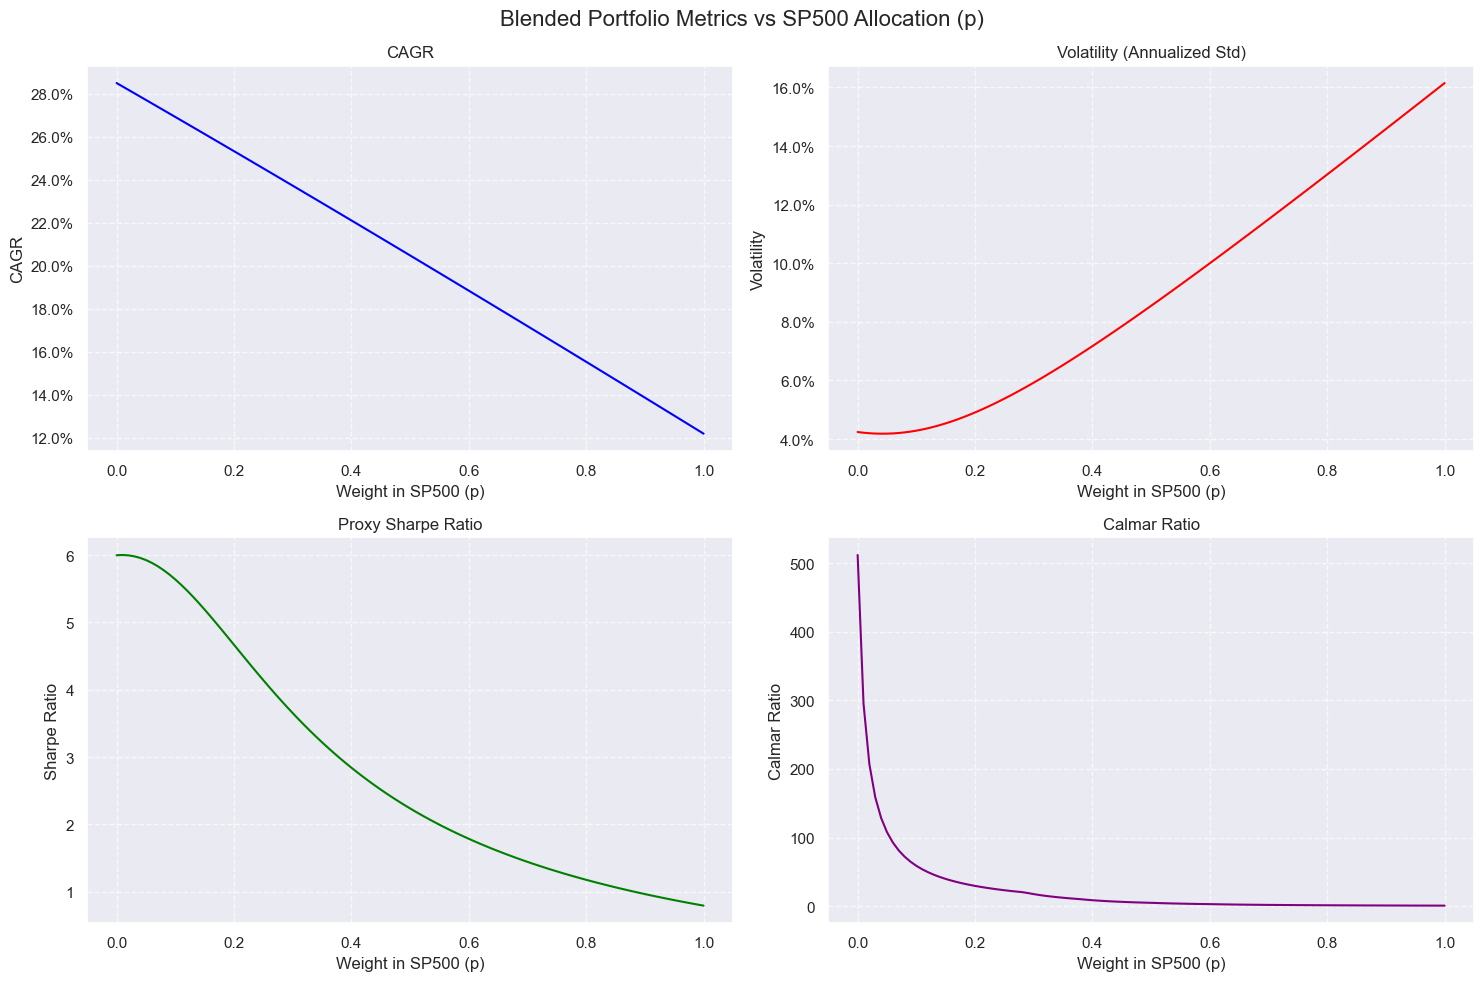

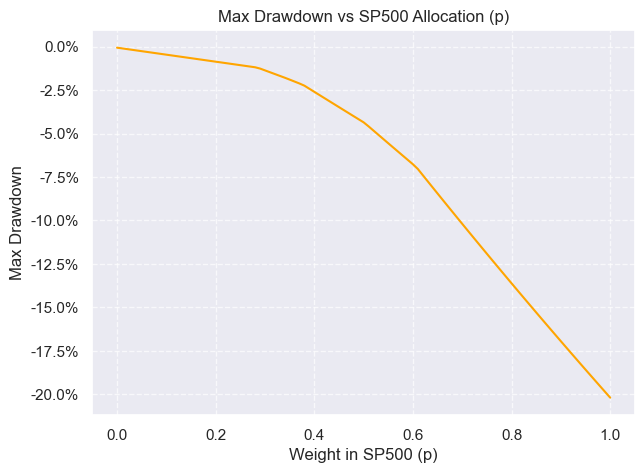

In [24]:
# --- Blended Portfolio Analysis (SP500 + Target Portfolio) ---
# p% in the SP500 and (1-p)% in the target portfolio (port_6m)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Align port_6m and sp500 exactly
common_idx = port_6m.dropna().index.intersection(sp500.dropna().index)
target_ret = port_6m.loc[common_idx]
sp500_ret = sp500.loc[common_idx]

p_values = np.linspace(0, 1, 101) # 0 to 100% in SP500
results = []

for p in p_values:
    # Portfolio return: p * SP500 + (1-p) * Target
    blend_ret = p * sp500_ret + (1 - p) * target_ret
    
    n_months = len(blend_ret)
    n_years = n_months / 12
    
    cum_wealth = (1 + blend_ret).cumprod()
    cagr = cum_wealth.iloc[-1]**(1/n_years) - 1 if cum_wealth.iloc[-1] > 0 else np.nan
    
    std = blend_ret.std() * np.sqrt(12)
    sharpe = (blend_ret.mean() * 12) / std if std != 0 else np.nan
    
    peak = cum_wealth.cummax()
    mdd = ((cum_wealth - peak) / peak).min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    
    results.append({
        'p (SP500 Weight)': p,
        'CAGR': cagr,
        'Volatility': std,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': mdd,
        'Calmar Ratio': calmar
    })

blend_df = pd.DataFrame(results)

# Plotting the metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Blended Portfolio Metrics vs SP500 Allocation (p)', fontsize=16)

# CAGR
axes[0, 0].plot(blend_df['p (SP500 Weight)'], blend_df['CAGR'], color='blue')
axes[0, 0].set_title('CAGR')
axes[0, 0].set_xlabel('Weight in SP500 (p)')
axes[0, 0].set_ylabel('CAGR')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Volatility
axes[0, 1].plot(blend_df['p (SP500 Weight)'], blend_df['Volatility'], color='red')
axes[0, 1].set_title('Volatility (Annualized Std)')
axes[0, 1].set_xlabel('Weight in SP500 (p)')
axes[0, 1].set_ylabel('Volatility')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Sharpe Ratio
axes[1, 0].plot(blend_df['p (SP500 Weight)'], blend_df['Sharpe Ratio'], color='green')
axes[1, 0].set_title('Proxy Sharpe Ratio')
axes[1, 0].set_xlabel('Weight in SP500 (p)')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Calmar Ratio
axes[1, 1].plot(blend_df['p (SP500 Weight)'], blend_df['Calmar Ratio'], color='purple')
axes[1, 1].set_title('Calmar Ratio')
axes[1, 1].set_xlabel('Weight in SP500 (p)')
axes[1, 1].set_ylabel('Calmar Ratio')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Additional Plot: Max Drawdown
plt.figure(figsize=(7, 5))
plt.plot(blend_df['p (SP500 Weight)'], blend_df['Max Drawdown'], color='orange')
plt.title('Max Drawdown vs SP500 Allocation (p)')
plt.xlabel('Weight in SP500 (p)')
plt.ylabel('Max Drawdown')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.show()
